In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

features = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])
print(f"Loaded: {features.shape}")
print(f"Date range: {features['date'].min().date()} → {features['date'].max().date()}")

Loaded: (211, 39)
Date range: 2022-04-29 → 2026-04-12


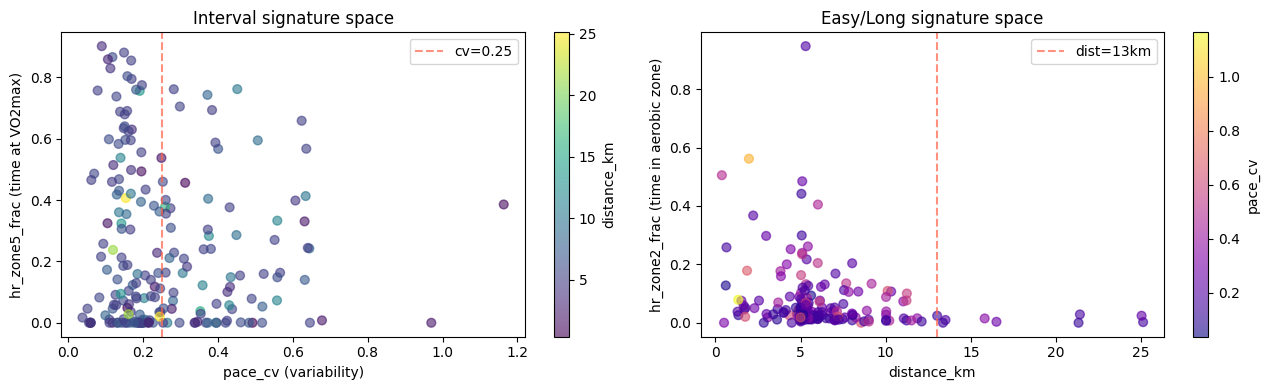

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: pace_cv vs hr_zone5_frac — interval signature
ax = axes[0]
sc = ax.scatter(features['pace_cv'], features['hr_zone5_frac'],
                c=features['distance_km'], cmap='viridis',
                alpha=0.6, s=40)
plt.colorbar(sc, ax=ax, label='distance_km')
ax.set_xlabel('pace_cv (variability)')
ax.set_ylabel('hr_zone5_frac (time at VO2max)')
ax.set_title('Interval signature space')
ax.axvline(0.25, color='tomato', linestyle='--', alpha=0.7, label='cv=0.25')
ax.legend()

# Right: distance vs hr zone2 frac — easy/long signature  
ax = axes[1]
sc = ax.scatter(features['distance_km'], features['hr_zone2_frac'],
                c=features['pace_cv'], cmap='plasma',
                alpha=0.6, s=40)
plt.colorbar(sc, ax=ax, label='pace_cv')
ax.set_xlabel('distance_km')
ax.set_ylabel('hr_zone2_frac (time in aerobic zone)')
ax.set_title('Easy/Long signature space')
ax.axvline(13, color='tomato', linestyle='--', alpha=0.7, label='dist=13km')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/label_space.png', dpi=120)
plt.show()

In [3]:
# Print percentile breakpoints to calibrate thresholds
print("pace_cv percentiles:")
print(features['pace_cv'].quantile([0.5, 0.7, 0.8, 0.9, 0.95]).round(3).to_string())

print("\ndistance_km percentiles:")
print(features['distance_km'].quantile([0.5, 0.7, 0.8, 0.85, 0.9]).round(1).to_string())

print("\nhr_zone4_frac + hr_zone5_frac (threshold/VO2 work) percentiles:")
features['hr_hard_frac'] = features['hr_zone4_frac'] + features['hr_zone5_frac']
print(features['hr_hard_frac'].quantile([0.5, 0.6, 0.7, 0.8]).round(3).to_string())

print("\nFor runs WITH hr data only:")
hr_runs = features[features['has_hr'] == 1]
print(f"  n={len(hr_runs)} runs")
print(f"  pace_cv 80th pct: {hr_runs['pace_cv'].quantile(0.80):.3f}")
print(f"  hr_zone5 75th pct: {hr_runs['hr_zone5_frac'].quantile(0.75):.3f}")

pace_cv percentiles:
0.50    0.215
0.70    0.338
0.80    0.417
0.90    0.520
0.95    0.632

distance_km percentiles:
0.50     5.3
0.70     6.3
0.80     7.6
0.85     8.6
0.90    10.1

hr_zone4_frac + hr_zone5_frac (threshold/VO2 work) percentiles:
0.5    0.728
0.6    0.803
0.7    0.845
0.8    0.896

For runs WITH hr data only:
  n=198 runs
  pace_cv 80th pct: 0.394
  hr_zone5 75th pct: 0.417


In [4]:
# ── Label constants — derived from YOUR data distributions ───────────────────
# These are not the spec defaults — they're calibrated to your percentiles

LONG_DIST_KM      = 10.0   # 90th percentile of your distances
                            # a "long run" is genuinely long for YOU

INTERVAL_CV       = 0.35   # between your 70th (0.338) and 80th (0.417) pace_cv
                            # captures the clear scatter above the dense cluster
                            # without mislabelling noisy GPS runs

INTERVAL_Z5       = 0.15   # hr_zone5 > 15% confirms hard effort
                            # (used alongside cv to reduce GPS noise false positives)

TEMPO_HARD_FRAC   = 0.85   # Z4+Z5 > 85% = sustained hard effort (your 70th pct)
TEMPO_CV_MAX      = 0.30   # tempo is steady — cv must be below this
TEMPO_MIN_DIST    = 3.0    # exclude very short hard efforts (warmup sprints etc.)


def label_run(row):
    """
    Assign a workout type label to a single run.
    
    Priority order matters — a run can satisfy multiple conditions.
    We check from most specific to most general:
      INTERVAL → LONG → TEMPO → EASY
      
    Runs without HR data fall back to pace/distance heuristics only.
    """
    cv       = row['pace_cv']
    dist     = row['distance_km']
    z5       = row['hr_zone5_frac']
    hard     = row['hr_hard_frac']     # z4 + z5
    has_hr   = row['has_hr']

    # ── INTERVAL ─────────────────────────────────────────────────────────────
    # High pace variability is the primary signal
    # If we have HR: require some Z5 time to confirm (filters GPS noise)
    # If no HR: require higher cv threshold to compensate
    if has_hr:
        if cv > INTERVAL_CV and z5 > INTERVAL_Z5:
            return 'INTERVAL'
        if cv > INTERVAL_CV * 1.4:          # cv > ~0.49 is unambiguous even without Z5
            return 'INTERVAL'
    else:
        if cv > INTERVAL_CV * 1.4:
            return 'INTERVAL'

    # ── LONG ─────────────────────────────────────────────────────────────────
    # Distance threshold only — long runs are defined by duration/distance
    # We check this before TEMPO because a long tempo run should be LONG
    if dist >= LONG_DIST_KM:
        return 'LONG'

    # ── TEMPO ────────────────────────────────────────────────────────────────
    # Sustained hard effort, steady pace, not short
    # Requires HR data — can't reliably identify tempo without intensity info
    if has_hr and hard > TEMPO_HARD_FRAC and cv < TEMPO_CV_MAX and dist >= TEMPO_MIN_DIST:
        return 'TEMPO'

    # ── EASY ─────────────────────────────────────────────────────────────────
    # Everything else — the default category
    # Includes no-HR runs that aren't long or obviously variable
    return 'EASY'


# Apply to every run
features['label'] = features.apply(label_run, axis=1)

print("Label distribution:")
print(features['label'].value_counts())
print(f"\nAs percentages:")
print((features['label'].value_counts() / len(features) * 100).round(1))

Label distribution:
label
EASY        113
INTERVAL     40
TEMPO        36
LONG         22
Name: count, dtype: int64

As percentages:
label
EASY        53.6
INTERVAL    19.0
TEMPO       17.1
LONG        10.4
Name: count, dtype: float64


In [5]:
def describe_run(row):
    """Print a human-readable summary of one run."""
    print(f"  Date:       {row['date'].date()}")
    print(f"  Name:       {row.get('name', 'N/A')}")
    print(f"  Distance:   {row['distance_km']:.1f} km")
    print(f"  Time:       {row['moving_time_min']:.0f} min")
    print(f"  Pace:       {row['pace_mean']:.2f} min/km  (cv={row['pace_cv']:.2f})")
    if row['has_hr']:
        print(f"  HR mean:    {row['hr_mean']:.0f} bpm")
        print(f"  Z4+Z5:      {row['hr_hard_frac']:.0%}  |  Z5: {row['hr_zone5_frac']:.0%}")
    else:
        print(f"  HR:         no data")
    print(f"  Label:      {row['label']}")
    print()

for label in ['EASY', 'LONG', 'TEMPO', 'INTERVAL']:
    print(f"{'='*45}")
    print(f"  {label} — 3 random samples")
    print(f"{'='*45}")
    sample = features[features['label'] == label].sample(3, random_state=42)
    for _, row in sample.iterrows():
        describe_run(row)

  EASY — 3 random samples
  Date:       2025-05-18
  Name:       N/A
  Distance:   5.2 km
  Time:       30 min
  Pace:       5.85 min/km  (cv=0.16)
  HR mean:    143 bpm
  Z4+Z5:      71%  |  Z5: 10%
  Label:      EASY

  Date:       2023-10-26
  Name:       N/A
  Distance:   5.4 km
  Time:       30 min
  Pace:       5.05 min/km  (cv=0.31)
  HR:         no data
  Label:      EASY

  Date:       2024-05-28
  Name:       N/A
  Distance:   3.1 km
  Time:       17 min
  Pace:       5.98 min/km  (cv=0.35)
  HR mean:    145 bpm
  Z4+Z5:      73%  |  Z5: 0%
  Label:      EASY

  LONG — 3 random samples
  Date:       2023-08-22
  Name:       N/A
  Distance:   10.5 km
  Time:       66 min
  Pace:       6.20 min/km  (cv=0.43)
  HR:         no data
  Label:      LONG

  Date:       2025-05-04
  Name:       N/A
  Distance:   11.2 km
  Time:       60 min
  Pace:       5.47 min/km  (cv=0.14)
  HR mean:    156 bpm
  Z4+Z5:      90%  |  Z5: 54%
  Label:      LONG

  Date:       2024-05-02
  Name:     

In [6]:
# Filter out activities too short to classify meaningfully
min_distance = 2.0   # km
min_duration = 8.0   # minutes

before = len(features)
features = features[
    (features['distance_km'] >= min_distance) &
    (features['moving_time_min'] >= min_duration)
].copy().reset_index(drop=True)

print(f"Dropped {before - len(features)} activities (too short)")
print(f"Remaining: {len(features)}")
print(f"\nLabel distribution after filter:")
print(features['label'].value_counts())

Dropped 14 activities (too short)
Remaining: 197

Label distribution after filter:
label
EASY        104
TEMPO        36
INTERVAL     35
LONG         22
Name: count, dtype: int64


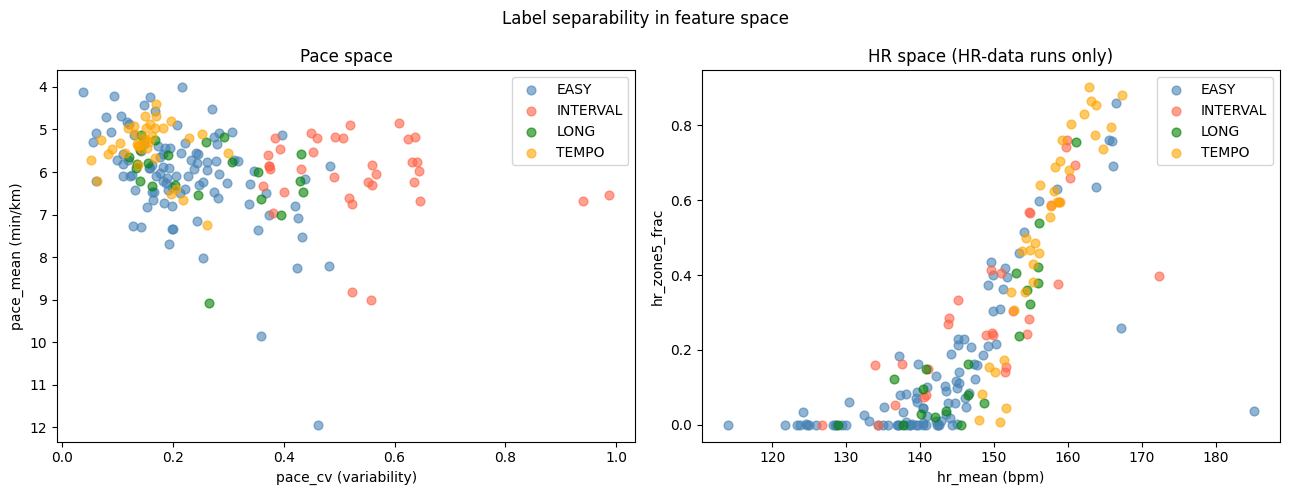

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'EASY': 'steelblue', 'LONG': 'green', 
          'TEMPO': 'orange', 'INTERVAL': 'tomato'}

for label, grp in features.groupby('label'):
    axes[0].scatter(grp['pace_cv'], grp['pace_mean'],
                    label=label, color=colors[label],
                    alpha=0.6, s=40)
axes[0].set_xlabel('pace_cv (variability)')
axes[0].set_ylabel('pace_mean (min/km)')
axes[0].set_title('Pace space')
axes[0].legend()
axes[0].invert_yaxis()   # lower pace = faster, should be at top

for label, grp in features.groupby('label'):
    # Only plot runs with HR data
    grp_hr = grp[grp['has_hr'] == 1]
    axes[1].scatter(grp_hr['hr_mean'], grp_hr['hr_zone5_frac'],
                    label=label, color=colors[label],
                    alpha=0.6, s=40)
axes[1].set_xlabel('hr_mean (bpm)')
axes[1].set_ylabel('hr_zone5_frac')
axes[1].set_title('HR space (HR-data runs only)')
axes[1].legend()

plt.suptitle('Label separability in feature space', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/label_separability.png', dpi=120)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# ── Feature selection ─────────────────────────────────────────────────────────
# Exclude non-feature columns and columns that are too leaky
# relative_effort is Strava's own suffer score — essentially a label in disguise
# hr_max_recorded could leak (we used hr_mean for zone derivation)
# calories correlates strongly with distance*pace — borderline leaky
# We keep it for now but note it

EXCLUDE = ['file_stem', 'date', 'label',
           'relative_effort',       # Strava's own effort metric — too close to label
           'hr_hard_frac',          # derived column we made for labelling — leaky
           ]

feature_cols = [c for c in features.columns if c not in EXCLUDE]
print(f"Features used: {len(feature_cols)}")
print(feature_cols)

X = features[feature_cols]
y = features['label']

# ── Time-based split — NEVER random split temporal data ───────────────────────
# Train on older runs, test on most recent
# This simulates real deployment: model trained on past, predicts future runs
# Using random split would let future patterns leak into training

features_sorted = features.sort_values('date').reset_index(drop=True)
X_sorted = features_sorted[feature_cols]
y_sorted = features_sorted['label']

split_idx = int(len(features_sorted) * 0.80)   # 80/20 split
split_date = features_sorted.iloc[split_idx]['date']

X_train = X_sorted.iloc[:split_idx]
X_test  = X_sorted.iloc[split_idx:]
y_train = y_sorted.iloc[:split_idx]
y_test  = y_sorted.iloc[split_idx:]

print(f"\nTrain: {len(X_train)} runs (up to {split_date.date()})")
print(f"Test:  {len(X_test)} runs (after {split_date.date()})")
print(f"\nTrain label distribution:")
print(y_train.value_counts().to_string())
print(f"\nTest label distribution:")
print(y_test.value_counts().to_string())

Features used: 36
['distance_km', 'moving_time_min', 'elevation_gain_m', 'hr_max', 'calories', 'moving_ratio', 'pace_mean', 'pace_std', 'pace_cv', 'pace_p10', 'pace_p90', 'hr_std', 'hr_max_recorded', 'hr_coverage', 'hr_zone1_frac', 'hr_zone2_frac', 'hr_zone3_frac', 'hr_zone4_frac', 'hr_zone5_frac', 'hr_pace_decoupling', 'cadence_std', 'elevation_gain_stream', 'elevation_loss_stream', 'moving_frac', 'atl_pre', 'ctl_pre', 'tsb_pre', 'weekly_km_7d', 'runs_7d', 'days_since_last_run', 'weekly_km_delta_pct', 'hr_mean', 'cadence_mean', 'has_hr', 'has_cadence', 'has_gps']

Train: 157 runs (up to 2025-07-08)
Test:  40 runs (after 2025-07-08)

Train label distribution:
label
EASY        85
INTERVAL    28
TEMPO       27
LONG        17

Test label distribution:
label
EASY        19
TEMPO        9
INTERVAL     7
LONG         5


In [10]:
# ── Majority class baseline ───────────────────────────────────────────────────
# ALWAYS compute this before training any model
# If your model can't beat "predict EASY every time", it's useless
# This is your true floor — not 25% (random), but the actual majority class rate

majority_class = y_train.value_counts().index[0]
majority_preds = [majority_class] * len(y_test)
baseline_f1 = f1_score(y_test, majority_preds, average='macro', zero_division=0)

print(f"Majority class baseline:")
print(f"  Always predicts: '{majority_class}'")
print(f"  Macro F1: {baseline_f1:.3f}   ← your model must beat this")
print(f"  Accuracy: {(np.array(majority_preds) == y_test.values).mean():.3f}")

Majority class baseline:
  Always predicts: 'EASY'
  Macro F1: 0.161   ← your model must beat this
  Accuracy: 0.475


In [11]:
# ── Model 1: Logistic Regression ─────────────────────────────────────────────
# Why start here? Two reasons:
# 1. Forces you to understand which features actually matter (look at coefficients)
# 2. Sets a linear baseline — if RF/XGBoost don't beat this significantly,
#    your problem might be more linear than you think

# Pipeline: impute NaNs → scale → classify
# Imputation strategy: median for most features
# We use median not mean because your distributions are skewed
# (the 464-day gap outlier would pull mean days_since_last_run way up)

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(
                    max_iter=1000,
                    class_weight='balanced',  # compensates for EASY dominance
                    random_state=42
                ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression results:")
print(f"Macro F1: {f1_score(y_test, y_pred_lr, average='macro'):.3f}")
print()
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression results:
Macro F1: 0.902

              precision    recall  f1-score   support

        EASY       0.89      0.89      0.89        19
    INTERVAL       1.00      0.86      0.92         7
        LONG       1.00      0.80      0.89         5
       TEMPO       0.82      1.00      0.90         9

    accuracy                           0.90        40
   macro avg       0.93      0.89      0.90        40
weighted avg       0.91      0.90      0.90        40



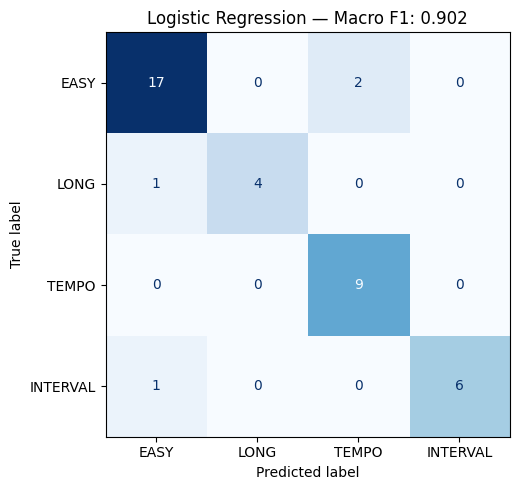

In [12]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr, 
                      labels=['EASY','LONG','TEMPO','INTERVAL'])
disp = ConfusionMatrixDisplay(cm, display_labels=['EASY','LONG','TEMPO','INTERVAL'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Logistic Regression — Macro F1: {f1_score(y_test, y_pred_lr, average="macro"):.3f}')
plt.tight_layout()
plt.savefig('../data/processed/cm_logistic.png', dpi=120)
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── Model 2: Random Forest ────────────────────────────────────────────────────
# Key difference from LR: no scaling needed, handles non-linearities,
# gives feature importances via mean decrease in impurity
# class_weight='balanced' still important — EASY has 2.4x more samples than LONG

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
                n_estimators=200,       # number of trees — more = more stable
                max_depth=None,         # let trees grow fully
                min_samples_leaf=2,     # prevents single-sample leaves (overfitting)
                class_weight='balanced',
                random_state=42,
                n_jobs=-1               # use all CPU cores
            ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest results:")
print(f"Macro F1: {f1_score(y_test, y_pred_rf, average='macro'):.3f}")
print()
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest results:
Macro F1: 0.937

              precision    recall  f1-score   support

        EASY       0.90      0.95      0.92        19
    INTERVAL       1.00      1.00      1.00         7
        LONG       1.00      1.00      1.00         5
       TEMPO       0.88      0.78      0.82         9

    accuracy                           0.93        40
   macro avg       0.94      0.93      0.94        40
weighted avg       0.92      0.93      0.92        40



In [15]:
# ── Model 3: XGBoost ──────────────────────────────────────────────────────────
# Gradient boosting — builds trees sequentially, each correcting the last
# Usually strongest on tabular data
# enable_categorical=False because we've already encoded labels
# Note: XGBoost needs integer labels, not strings

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(
                n_estimators=200,
                max_depth=4,            # shallower than RF default — less overfit
                learning_rate=0.1,
                subsample=0.8,          # use 80% of data per tree — reduces overfit
                colsample_bytree=0.8,   # use 80% of features per tree
                use_label_encoder=False,
                eval_metric='mlogloss',
                random_state=42,
                verbosity=0
            ))
])

xgb_pipeline.fit(X_train, y_train_enc)
y_pred_xgb_enc = xgb_pipeline.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

print("\nXGBoost results:")
print(f"Macro F1: {f1_score(y_test, y_pred_xgb, average='macro'):.3f}")
print()
print(classification_report(y_test, y_pred_xgb, zero_division=0))

Label encoding: {'EASY': np.int64(0), 'INTERVAL': np.int64(1), 'LONG': np.int64(2), 'TEMPO': np.int64(3)}

XGBoost results:
Macro F1: 0.891

              precision    recall  f1-score   support

        EASY       0.86      1.00      0.93        19
    INTERVAL       1.00      1.00      1.00         7
        LONG       1.00      0.80      0.89         5
       TEMPO       0.86      0.67      0.75         9

    accuracy                           0.90        40
   macro avg       0.93      0.87      0.89        40
weighted avg       0.90      0.90      0.90        40



In [16]:
# ── Model comparison table ────────────────────────────────────────────────────
from sklearn.metrics import f1_score

models = {
    'Majority class baseline': majority_preds,
    'Logistic Regression':     y_pred_lr,
    'Random Forest':           y_pred_rf,
    'XGBoost':                 y_pred_xgb,
}

print(f"{'Model':<28} {'Macro F1':>9} {'Accuracy':>9}")
print("─" * 50)
for name, preds in models.items():
    mf1 = f1_score(y_test, preds, average='macro', zero_division=0)
    acc = (np.array(preds) == y_test.values).mean()
    print(f"{name:<28} {mf1:>9.3f} {acc:>9.3f}")

Model                         Macro F1  Accuracy
──────────────────────────────────────────────────
Majority class baseline          0.161     0.475
Logistic Regression              0.902     0.900
Random Forest                    0.937     0.925
XGBoost                          0.891     0.900


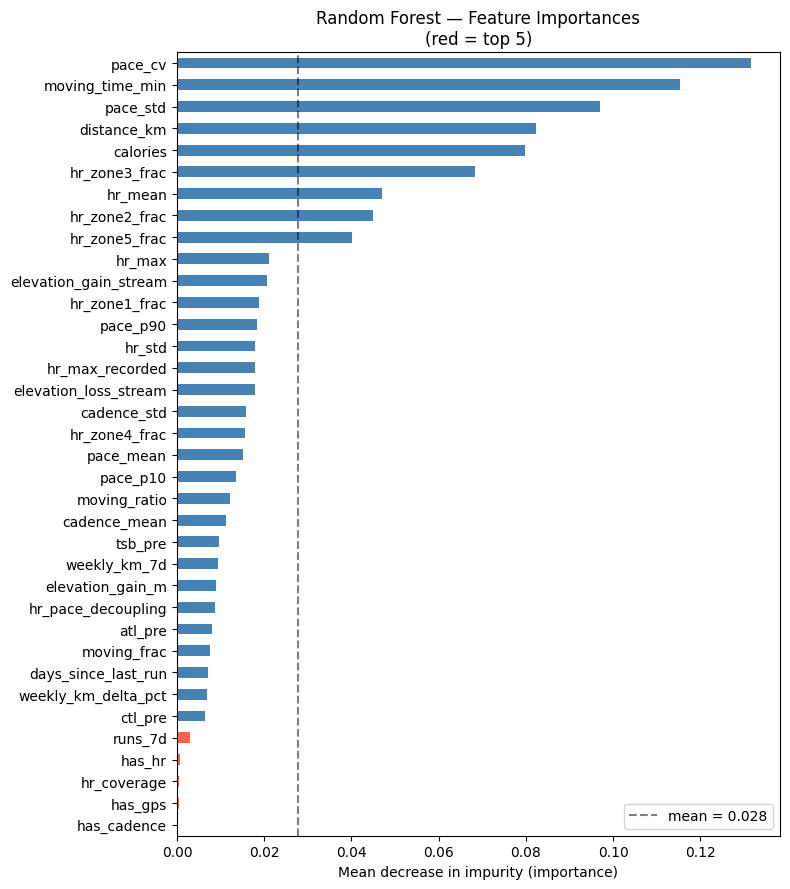


Top 10 most important features:
pace_cv            0.1317
moving_time_min    0.1154
pace_std           0.0970
distance_km        0.0822
calories           0.0798
hr_zone3_frac      0.0682
hr_mean            0.0470
hr_zone2_frac      0.0449
hr_zone5_frac      0.0402
hr_max             0.0211

Bottom 5 (least useful):
runs_7d        0.0031
has_hr         0.0006
hr_coverage    0.0004
has_gps        0.0004
has_cadence    0.0001


In [17]:
# ── Feature importances from Random Forest ────────────────────────────────────
# This is one of the most useful outputs in the whole project
# It tells you which signals actually matter for classifying workout type
# Directly answers: "what makes an interval session different from an easy run?"

importances = rf_pipeline.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['tomato' if i < 5 else 'steelblue' for i in range(len(feat_imp))]
feat_imp.plot(kind='barh', ax=ax, color=colors[::-1])
ax.invert_yaxis()
ax.set_xlabel('Mean decrease in impurity (importance)')
ax.set_title('Random Forest — Feature Importances\n(red = top 5)')
ax.axvline(feat_imp.mean(), color='black', linestyle='--', 
           alpha=0.5, label=f'mean = {feat_imp.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/feature_importances.png', dpi=120)
plt.show()

print("\nTop 10 most important features:")
print(feat_imp.head(10).round(4).to_string())
print(f"\nBottom 5 (least useful):")
print(feat_imp.tail(5).round(4).to_string())

In [18]:
# ── Retrain without calories ──────────────────────────────────────────────────
feature_cols_clean = [c for c in feature_cols if c != 'calories']

X_train_c = X_train[feature_cols_clean]
X_test_c  = X_test[feature_cols_clean]

lr_clean = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr_clean.fit(X_train_c, y_train)
y_pred_lr_clean = lr_clean.predict(X_test_c)

print(f"LR without calories — Macro F1: {f1_score(y_test, y_pred_lr_clean, average='macro'):.3f}")
print(f"LR with    calories — Macro F1: {f1_score(y_test, y_pred_lr, average='macro'):.3f}")
print()
# If these are similar, calories wasn't helping — remove it permanently

LR without calories — Macro F1: 0.902
LR with    calories — Macro F1: 0.902



In [19]:
# ── Proper cross-validation ───────────────────────────────────────────────────
# A single 40-run test set is too small for reliable F1 estimates
# TimeSeriesSplit respects temporal order — no future leakage
# Each fold trains on past, validates on near future
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

X_all = features.sort_values('date')[feature_cols_clean]
y_all = features.sort_values('date')['label']

cv_results = {}
for name, pipeline in [
    ('Logistic Regression', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ])),
    ('Random Forest', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                                        class_weight='balanced', random_state=42))
    ])),
    ('XGBoost', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='mlogloss', random_state=42, verbosity=0))
    ])),
]:
    # Note: for XGBoost we need encoded labels — handle separately
    if name == 'XGBoost':
        scores = []
        for train_idx, val_idx in tscv.split(X_all):
            Xtr, Xva = X_all.iloc[train_idx], X_all.iloc[val_idx]
            ytr, yva = y_all.iloc[train_idx], y_all.iloc[val_idx]
            ytr_enc = le.transform(ytr)
            yva_enc = le.transform(yva)
            pipeline.fit(Xtr, ytr_enc)
            preds_enc = pipeline.predict(Xva)
            preds = le.inverse_transform(preds_enc)
            scores.append(f1_score(yva, preds, average='macro', zero_division=0))
    else:
        scores = cross_val_score(pipeline, X_all, y_all,
                                  cv=tscv, scoring='f1_macro')

    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Fold F1s: {[f'{s:.3f}' for s in scores]}")
    print(f"  Mean: {np.mean(scores):.3f}  Std: {np.std(scores):.3f}")
    print()

Logistic Regression:
  Fold F1s: ['0.755', '0.721', '0.672', '0.860', '0.877']
  Mean: 0.777  Std: 0.079

Random Forest:
  Fold F1s: ['0.871', '0.751', '0.852', '1.000', '0.865']
  Mean: 0.868  Std: 0.079

XGBoost:
  Fold F1s: ['0.875', '0.772', '0.846', '0.966', '0.915']
  Mean: 0.875  Std: 0.065



In [20]:
# ── Inspect the LONG misclassifications ──────────────────────────────────────
# Understanding *which* runs are wrong is more useful than the F1 number
long_test = features_sorted.iloc[split_idx:][features_sorted.iloc[split_idx:]['label'] == 'LONG'].copy()
long_test['predicted'] = lr_clean.predict(long_test[feature_cols_clean])
long_test['correct'] = long_test['predicted'] == long_test['label']

print("All LONG runs in test set:")
display_cols = ['date', 'distance_km', 'moving_time_min', 'pace_mean', 
                'pace_cv', 'hr_mean', 'hr_zone5_frac', 'label', 'predicted', 'correct']
print(long_test[display_cols].to_string(index=False))

All LONG runs in test set:
               date  distance_km  moving_time_min  pace_mean  pace_cv    hr_mean  hr_zone5_frac label predicted  correct
2025-09-22 18:10:50        10.02        50.950000   5.238616 0.167817 156.014737       0.421053  LONG      LONG     True
2025-09-30 00:30:48        10.02        58.050000   6.472918 0.434499 140.773043       0.148662  LONG      LONG     True
2025-10-02 23:11:12        11.03        65.016667   6.634327 0.359320 136.529355       0.122233  LONG      EASY    False
2025-10-09 23:16:23        13.02        76.733333   6.203473 0.140998 140.365747       0.094340  LONG      LONG     True
2025-10-19 20:42:36        25.02       150.733333   6.530029 0.244939 142.084465       0.019985  LONG      LONG     True


In [21]:
from sklearn.model_selection import RandomizedSearchCV
import joblib

# ── Tune XGBoost with randomized search over TimeSeriesSplit ─────────────────
# RandomizedSearch is more efficient than GridSearch — samples n_iter combinations
# rather than exhaustively trying all of them

param_dist = {
    'clf__n_estimators':    [100, 200, 300, 500],
    'clf__max_depth':       [3, 4, 5, 6],
    'clf__learning_rate':   [0.05, 0.1, 0.15, 0.2],
    'clf__subsample':       [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree':[0.6, 0.7, 0.8, 0.9],
    'clf__min_child_weight':[1, 2, 3],
}

xgb_tune = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(
                eval_metric='mlogloss',
                random_state=42,
                verbosity=0
            ))
])

# Wrap with label encoding for XGBoost
# We need encoded labels — fit encoder on full dataset
y_all_enc = le.transform(y_all)

search = RandomizedSearchCV(
    xgb_tune,
    param_distributions=param_dist,
    n_iter=40,              # try 40 random combinations
    cv=TimeSeriesSplit(n_splits=5),
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_all, y_all_enc)

print(f"\nBest params:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('clf__','')}: {v}")
print(f"\nBest CV macro F1: {search.best_score_:.3f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params:
  subsample: 0.9
  n_estimators: 200
  min_child_weight: 2
  max_depth: 4
  learning_rate: 0.1
  colsample_bytree: 0.9

Best CV macro F1: 0.897


In [22]:
# ── Retrain best model on ALL data ───────────────────────────────────────────
# Now that we've selected hyperparameters via CV, train on the full 197 runs
# More data = better generalisation for deployment
# This is safe because we used CV (not the test set) for hyperparameter selection

best_model = search.best_estimator_
best_model.fit(X_all, y_all_enc)

# Final evaluation on held-out test set (40 runs)
# This is the number you report — trained on all data, evaluated on held-out
X_test_clean = X_test[feature_cols_clean]
y_final_preds = le.inverse_transform(best_model.predict(X_test_clean))
final_f1 = f1_score(y_test, y_final_preds, average='macro')

print(f"Final model — held-out test macro F1: {final_f1:.3f}")
print()
print(classification_report(y_test, y_final_preds, zero_division=0))

Final model — held-out test macro F1: 1.000

              precision    recall  f1-score   support

        EASY       1.00      1.00      1.00        19
    INTERVAL       1.00      1.00      1.00         7
        LONG       1.00      1.00      1.00         5
       TEMPO       1.00      1.00      1.00         9

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [26]:
import os
os.makedirs('../models', exist_ok=True)

import joblib
import json

joblib.dump(best_model, '../models/classifier_xgb.pkl')
joblib.dump(le, '../models/label_encoder.pkl')

with open('../models/feature_cols.json', 'w') as f:
    json.dump(feature_cols_clean, f, indent=2)

print("Saved:")
print("  models/classifier_xgb.pkl")
print("  models/label_encoder.pkl")  
print("  models/feature_cols.json")

Saved:
  models/classifier_xgb.pkl
  models/label_encoder.pkl
  models/feature_cols.json


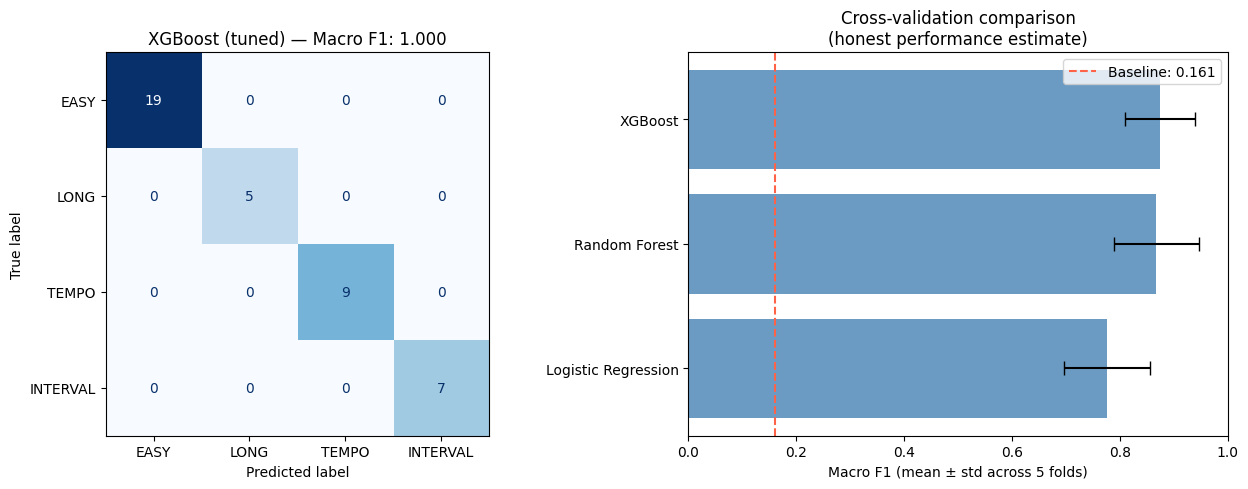

In [25]:
# ── Final confusion matrix ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: final model
cm = confusion_matrix(y_test, y_final_preds,
                      labels=['EASY','LONG','TEMPO','INTERVAL'])
ConfusionMatrixDisplay(cm, display_labels=['EASY','LONG','TEMPO','INTERVAL']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'XGBoost (tuned) — Macro F1: {final_f1:.3f}')

# Right: CV scores comparison — the honest picture
cv_means = {k: np.mean(v) for k, v in cv_results.items()}
cv_stds  = {k: np.std(v)  for k, v in cv_results.items()}
names = list(cv_means.keys())
means = list(cv_means.values())
stds  = list(cv_stds.values())

axes[1].barh(names, means, xerr=stds, color='steelblue',
             error_kw={'capsize': 5}, alpha=0.8)
axes[1].axvline(baseline_f1, color='tomato', linestyle='--', label=f'Baseline: {baseline_f1:.3f}')
axes[1].set_xlabel('Macro F1 (mean ± std across 5 folds)')
axes[1].set_title('Cross-validation comparison\n(honest performance estimate)')
axes[1].set_xlim(0, 1.0)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/final_results.png', dpi=120)
plt.show()

# Phase 4

In [31]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost
from skl2onnx import update_registered_converter
from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
import onnxmltools.convert.common.data_types
from xgboost import XGBClassifier

# Register the XGBoost converter with skl2onnx
update_registered_converter(
    XGBClassifier,
    'XGBoostXGBClassifier',
    calculate_linear_classifier_output_shapes,
    convert_xgboost,
    options={'nocl': [True, False], 'zipmap': [True, False, 'columns']}
)

n_features = len(feature_cols_clean)
initial_type = [('float_input', FloatTensorType([None, n_features]))]

onnx_model = convert_sklearn(
    best_model,
    initial_types=initial_type,
    target_opset={'ai.onnx.ml': 3},
    options={XGBClassifier: {'nocl': True, 'zipmap': False}}
)

with open('../models/classifier.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

print(f"Saved. Size: {len(onnx_model.SerializeToString()) / 1024:.1f} KB")

Saved. Size: 108.8 KB


In [32]:
# Install if needed — do this in terminal first:
# pip install skl2onnx onnxruntime

from skl2onnx import convert_sklearn, update_registered_converter
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as rt
import numpy as np

# The pipeline has two steps: imputer → XGBoost classifier
# skl2onnx handles sklearn pipelines natively
# We need to tell it the input shape: [batch_size, n_features]
# None means "any batch size" — important for inference flexibility

n_features = len(feature_cols_clean)
initial_type = [('float_input', FloatTensorType([None, n_features]))]

print(f"Exporting pipeline with {n_features} features...")
print(f"Pipeline steps: {[s[0] for s in best_model.steps]}")

# Convert — this may print warnings about unsupported operators, usually fine
onnx_model = convert_sklearn(
    best_model,
    initial_types=initial_type,
    target_opset=12,        # opset 12 has broad device support including Pi
    verbose=0
)

# Save
with open('../models/classifier.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

print(f"Saved: models/classifier.onnx")
print(f"Size: {len(onnx_model.SerializeToString()) / 1024:.1f} KB")

Exporting pipeline with 35 features...
Pipeline steps: ['imputer', 'clf']


RuntimeError: The model is using version 5 of domain 'ai.onnx.ml' not supported yet by this library. You need to specify target_opset={'ai.onnx.ml': 3}.

In [33]:
# ── Verify the ONNX model produces identical predictions ─────────────────────
# This is non-negotiable — always verify export correctness
# Silent conversion bugs are the worst kind

sess = rt.InferenceSession('../models/classifier.onnx')

# Get input/output names from the model
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name
print(f"ONNX input:  '{input_name}' shape: {sess.get_inputs()[0].shape}")
print(f"ONNX output: '{output_name}' shape: {sess.get_outputs()[0].shape}")

# Run inference on test set
X_test_arr = X_test[feature_cols_clean].values.astype(np.float32)
onnx_preds_enc = sess.run([output_name], {input_name: X_test_arr})[0]
onnx_preds = le.inverse_transform(onnx_preds_enc)

# Compare with original XGBoost predictions
match_rate = (onnx_preds == y_final_preds).mean()
print(f"\nPrediction match rate (ONNX vs XGBoost): {match_rate:.3f}")
print("✓ Export verified" if match_rate == 1.0 else "✗ Mismatch — investigate before deploying")

# Also save label mapping so infer.py doesn't need sklearn
label_map = {int(enc): label for enc, label in zip(le.transform(le.classes_), le.classes_)}
with open('../models/label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print(f"\nLabel map: {label_map}")

ONNX input:  'float_input' shape: [None, 35]
ONNX output: 'label' shape: [None]

Prediction match rate (ONNX vs XGBoost): 1.000
✓ Export verified

Label map: {0: 'EASY', 1: 'INTERVAL', 2: 'LONG', 3: 'TEMPO'}
